# This the notebook with the model

Here will be the whole workflow with the model building

In [1]:
!pip install word2number
!pip install num2words
!pip install gensim
!pip install skorch

In [2]:
#@title Plotting function

def plot_pred_vs_true(predictions, trues, model_name):
  fig, ax  = plt.subplots(1,1)
  sns.scatterplot(x=trues.reshape(-1), y=predictions.reshape(-1))
  ax.set_xlabel("Actual Prices")
  ax.set_ylabel("Predicted Prices")
  ax.set_title(f"Actual Prices vs Predicted Prices with {model_name}")

  # Plot identity line in red
  min_val = min(trues.min(), predictions.min())
  max_val = max(trues.max(), predictions.max())
  ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Identity Line')

  plt.show()


In [3]:
# load the google news 300 word2vec model
import gensim.downloader as api
w2v = api.load('word2vec-google-news-300') # loads for a couple of minutes

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [87]:
# load the data
train_path = os.path.join( "train_listings.csv")
test_path = os.path.join( "test_listings.csv")
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

#Preporcess the data

In [88]:
from data_prepocessing import full_preprocess
train_df = full_preprocess(train_df)
test_df = full_preprocess(test_df)

/content/data_prepocessing.py:41: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["price"].replace({r'\$': '',',':''}, regex=True, inplace=True)
/content/data_prepocessing.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["price"].replace({r'\$': '',',':''}, regex=True, inplace=True)
/content/data_prepocessing.py:43: SettingWithCopyWarn

In [89]:
train_df = train_df.dropna()
test_df = test_df.dropna()

In [90]:
# split the data into X and y
X_train = train_df.drop(columns=["price"])
y_train = train_df["price"]

X_test = test_df.drop(columns=["price"])
y_test = test_df["price"]

# normilize the numeric data

In [91]:
numerical_features = ["accommodates", "bedrooms", "beds", "bathrooms"]
X_num_train = X_train[numerical_features]
X_num_test = X_test[numerical_features]



In [92]:
# normilize using the MinMaxscaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X_num_train = scaler.fit_transform(X_num_train) # fit scaler and trasform the data for train
X_num_train = pd.DataFrame(X_num_train, columns=numerical_features, index=X_train.index)

X_num_test = scaler.transform(X_num_test) # trasform the test data using the same scaler
X_num_test = pd.DataFrame(X_num_test, columns=numerical_features, index=X_test.index)

# update the original dataset
X_train[numerical_features] = X_num_train
X_test[numerical_features] = X_num_test

In [11]:
# normilize the prices
#scaler = MinMaxScaler()
#y_train = scaler.fit_transform(pd.DataFrame(y_train))

#y_test = scaler.transform(pd.DataFrame(y_test))


In [12]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4767 entries, 0 to 5055
Data columns (total 49 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   description                4767 non-null   object 
 1   accommodates               4767 non-null   float64
 2   bedrooms                   4767 non-null   float64
 3   beds                       4767 non-null   float64
 4   bathrooms                  4767 non-null   float64
 5   room_type_Entire home/apt  4767 non-null   bool   
 6   room_type_Hotel room       4767 non-null   bool   
 7   room_type_Private room     4767 non-null   bool   
 8   room_type_Shared room      4767 non-null   bool   
 9   BabyAmenities              4767 non-null   bool   
 10  TV                         4767 non-null   bool   
 11  Sauna                      4767 non-null   bool   
 12  Safe                       4767 non-null   bool   
 13  HighChair                  4767 non-null   bool   
 1

# Process the bool data
Convert to float64 for the upcomming transition to torch.tensor

In [13]:
X_train = X_train.astype({col: 'float64' for col in X_train.select_dtypes(include='bool').columns})
X_test = X_test.astype({col: 'float64' for col in X_test.select_dtypes(include='bool').columns})


# Transform the description data into numercs with word2vec

Use Word2vec to convert words into numbers


In [14]:
# this is from https://github.com/hansonchang2008/house-price-prediction-web-app
class MeanEmbeddingVectorizer(object):
    def __init__(self, word2vec):
        self.word2vec = word2vec
        # if a text is empty we should return a vector of zeros
        # with the same dimensionality as all the other vectors
        self.dim = word2vec.vector_size


    def fit(self, X, y):
        return self

    def transform(self, X):
        return np.array([np.mean([self.word2vec[w] for w in words if w in self.word2vec] or [np.zeros(self.dim)], axis=0) for words in X])

def word2vec(df):
    model=w2v
    w2v = dict(zip(model.wv.index2word, model.wv.syn0))
    MEV=MeanEmbeddingVectorizer(w2v)
    w2v_df=MEV.transform(df)
    return w2v_df

In [15]:
MEV=MeanEmbeddingVectorizer(w2v)

# transform the train data
X_text_train = X_train['description']
transformed_X_train=MEV.transform(X_text_train)
X_text_df_train = pd.DataFrame(transformed_X_train, index=X_train.index)

#transform the test data
X_text_test = X_test['description']
transformed_X_test=MEV.transform(X_text_test)
X_text_df_test = pd.DataFrame(transformed_X_test, index=X_test.index)

In [16]:
# combine the whole prepocessed data

X_train = pd.concat([X_train.drop(columns=["description"]), X_text_df_train], axis=1)

X_test = pd.concat([X_test.drop(columns=["description"]), X_text_df_test], axis=1)


In [17]:
X_train = np.asarray(X_train).astype(np.float32)
y_train = np.ravel(y_train)


X_test = np.asarray(X_test).astype(np.float32)
y_test = np.ravel(y_test)

results = {}

# Linear Regression

In [36]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
# Define the Ridge regression model
ridge_regressor = Ridge()

# Define a parameter grid for tuning the model
param_grid = {
    'alpha': np.linspace(1e-3, 1e2, 1000), #[0.01, 0.1, 1.0, 10.0],  # Regularization strength
    'solver': ['auto']#, 'svd', 'cholesky', 'lsqr', 'sparse_cg'],  # Solver options
}

# Example target vector
y_train_flat = np.ravel(y_train)

# Set up the grid search
grid_search_ridge = GridSearchCV(estimator=ridge_regressor, param_grid=param_grid, cv=3, n_jobs=-1)

# Fit the model using grid search
grid_search_ridge.fit(X_train, y_train_flat)

# Display grid search results
print("-------------------------------------------------------------------")
print("Ridge Regression Grid Search Results")
print("-------------------------------------------------------------------")
print("\n The best estimator across ALL searched params:\n", grid_search_ridge.best_estimator_)
print("\n The best r2 score across ALL searched params:\n", grid_search_ridge.best_score_)
print("\n The best parameters across ALL searched params:\n", grid_search_ridge.best_params_)
print("\n")
print("-------------------------------------------------------------------")

-------------------------------------------------------------------
Ridge Regression Grid Search Results
-------------------------------------------------------------------

 The best estimator across ALL searched params:
 Ridge(alpha=1.7026846846846846)

 The best r2 score across ALL searched params:
 0.4480604027728153

 The best parameters across ALL searched params:
 {'alpha': 1.7026846846846846, 'solver': 'auto'}


-------------------------------------------------------------------


In [37]:
print("All Results:")
df_gridsearch_result = pd.DataFrame(grid_search_ridge.cv_results_).sort_values(by="rank_test_score")
df_gridsearch_result.head()


All Results:


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,param_solver,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
17,0.045667,0.003947,0.003780,0.000095,1.702685,auto,"{'alpha': 1.7026846846846846, 'solver': 'auto'}",0.418226,0.468253,0.457702,0.448060,0.021532,1
18,0.039942,0.001764,0.003223,0.000530,1.802784,auto,"{'alpha': 1.8027837837837837, 'solver': 'auto'}",0.418256,0.468304,0.457573,0.448044,0.021514,2
16,0.040463,0.000815,0.003636,0.000060,1.602586,auto,"{'alpha': 1.6025855855855855, 'solver': 'auto'}",0.418155,0.468163,0.457805,0.448041,0.021552,3
19,0.042771,0.004007,0.003869,0.000483,1.902883,auto,"{'alpha': 1.9028828828828828, 'solver': 'auto'}",0.418250,0.468320,0.457424,0.447998,0.021500,4
15,0.038839,0.001232,0.003749,0.000118,1.502486,auto,"{'alpha': 1.5024864864864864, 'solver': 'auto'}",0.418035,0.468026,0.457879,0.447980,0.021576,5


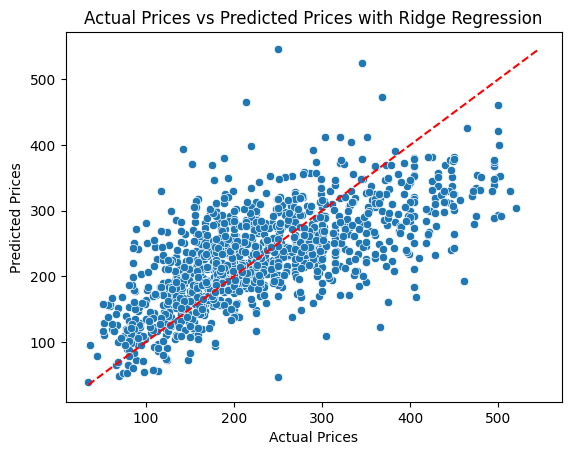

R2 score on test set: 0.466790627027561
MSE on test set: 5307.976378711927


In [38]:
from sklearn.metrics import r2_score, mean_squared_error
# Use the best estimator to make predictions on the test set
best_model = grid_search_ridge.best_estimator_

# Predict on the test set
y_pred = best_model.predict(X_test)

plot_pred_vs_true(y_pred, y_test, "Ridge Regression")

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

#save the results
results["Ridge"] = {"r2": r2, "mse": mse}
print("R2 score on test set:", r2)
print("MSE on test set:", mse)


# Gradient Boosting
I here use HistGradentBoostingRegressor, because its just way faster than the original one

In [21]:
from sklearn import ensemble
#GBR = ensemble.GradientBoostingRegressor()
HGBR = ensemble.HistGradientBoostingRegressor(max_iter=200, learning_rate=0.1,  l2_regularization=0)

param_grid = {
    'max_iter': [100, 200,500],
     'learning_rate': [0.1, 0.05, 0.01],
    # 'max_depth': [3, 5, None],
    # #'min_samples_leaf': [20, 50],
     'l2_regularization': [0.0, 0.001, 0.01],

}

y_train_flat=np.ravel(y_train)
#HGBR.fit(X_train, y_train_flat)
from sklearn.model_selection import GridSearchCV
grid_GBR = GridSearchCV(estimator=HGBR, param_grid = param_grid, cv = 3, n_jobs=-1)
grid_GBR.fit(X_train, y_train)

print("-------------------------------------------------------------------")
print("Gradient Boosting Grid Search Results")
print("-------------------------------------------------------------------")
print("\n The best estimator across ALL searched params:\n",grid_GBR.best_estimator_)
print("\n The best r2 score across ALL searched params:\n",grid_GBR.best_score_)
print("\n The best parameters across ALL searched params:\n",grid_GBR.best_params_)
print("\n")
print("-------------------------------------------------------------------")

#HGBR.score(X_train, y_train_flat)

-------------------------------------------------------------------
Gradient Boosting Grid Search Results
-------------------------------------------------------------------

 The best estimator across ALL searched params:
 HistGradientBoostingRegressor(l2_regularization=0.001, learning_rate=0.05,
                              max_iter=200)

 The best r2 score across ALL searched params:
 0.47230317336922073

 The best parameters across ALL searched params:
 {'l2_regularization': 0.001, 'learning_rate': 0.05, 'max_iter': 200}


-------------------------------------------------------------------


In [22]:
print("All Results:")
df_gridsearch_result = pd.DataFrame(grid_GBR.cv_results_).sort_values(by="rank_test_score")
df_gridsearch_result.head()


All Results:


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_l2_regularization,param_learning_rate,param_max_iter,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
13,15.242929,0.292827,0.111668,0.004572,0.001,0.05,200,"{'l2_regularization': 0.001, 'learning_rate': ...",0.452704,0.476750,0.487455,0.472303,0.014531,1
8,40.145912,0.681818,0.252153,0.018712,0.000,0.01,500,"{'l2_regularization': 0.0, 'learning_rate': 0....",0.452877,0.478073,0.483778,0.471576,0.013426,2
14,34.850390,1.090906,0.220980,0.006590,0.001,0.05,500,"{'l2_regularization': 0.001, 'learning_rate': ...",0.448052,0.477209,0.487844,0.471035,0.016821,3
23,33.533754,1.194877,0.299233,0.100192,0.010,0.05,500,"{'l2_regularization': 0.01, 'learning_rate': 0...",0.454742,0.473697,0.484220,0.470886,0.012197,4
22,15.398286,0.283299,0.117996,0.025018,0.010,0.05,200,"{'l2_regularization': 0.01, 'learning_rate': 0...",0.453350,0.474047,0.484358,0.470585,0.012893,5


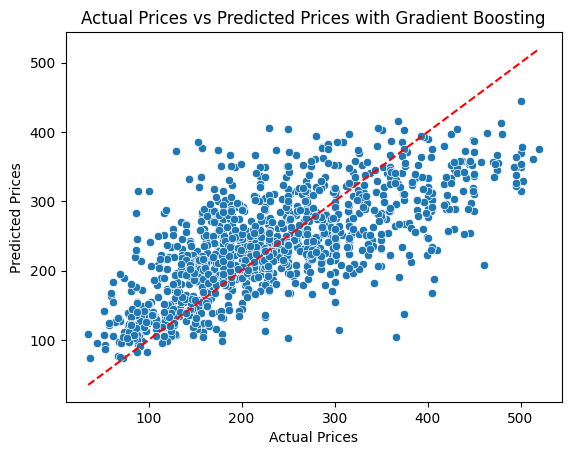

R2 score on test set: 0.49197391001435353
MSE on test set: 5057.282602480761


In [23]:
# Use the best estimator to make predictions on the test set
best_model = grid_GBR.best_estimator_

# Predict on the test set
y_pred = best_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

plot_pred_vs_true(y_pred, y_test, "Gradient Boosting")

#save the resuls
results["Gradient Boosting"] = {"r2": r2, "mse": mse}

print("R2 score on test set:", r2)
print("MSE on test set:", mse)


# DNN

In [24]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"

# set the seed for reproducibility
seed = 2025
np.random.seed(seed)
torch.manual_seed(seed)


## Create a dataset and a dataloader

In [27]:
# from torch.utils.data import DataLoader, TensorDataset
# transform to tensors and create dataloaders
X_train = torch.tensor(X_train).float()
y_train = torch.tensor(y_train).float()

# train_dataset = TensorDataset(X_train, y_train)
# train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)


## Define the model in Pytorch

In [28]:
import torch.nn as nn

class PricePredictor(nn.Module):
    def __init__(self, input_dim, neurons=50, dropout_rate=0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, neurons),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(neurons, neurons**2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(neurons**2, neurons),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(neurons, neurons),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(neurons, 1),
        )

    def forward(self, x):
        return self.net(x)


## Use Skorch to perform the fine tunning of the parameters

In [30]:
from skorch import NeuralNetRegressor
from skorch.callbacks import EarlyStopping
from torch import optim



# wrap the model in skorch
net = NeuralNetRegressor(
    module=PricePredictor,
    module__input_dim=X_train.shape[1],  # <- specify your input size
    module__neurons=50,
    module__dropout_rate=0.2,
    optimizer=optim.Adam,
    criterion=nn.MSELoss,
    max_epochs=500,
    lr=0.01,
    batch_size=64,
    iterator_train__shuffle=True,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    callbacks=[EarlyStopping(patience=20)]
)

# Define parameter grid
params = {
    'lr': [0.0001, 0.001, 0.01, 0.1],
    'module__neurons': [64 ,128, 256],
    'module__dropout_rate': [0.0 ,0.2,0.4],
    #'max_epochs' : [50,100,200]
}

# Perform the search

# 4. Perform grid search
gs = GridSearchCV(net, params, cv=3)
gs.fit(X_train, y_train.reshape(-1,1))


Streaming output truncated to the last 5000 lines.
     72     6605.2907     6787.4673  0.1454
     73     6747.2649     6775.9110  0.1487
     74     6779.5954     6735.5644  0.1427
     75     6481.0691     6738.1166  0.1435
     76     6827.7451     6748.0491  0.1458
     77     6794.3198     6730.7967  0.1579
     78     6567.8904     6718.6332  0.1504
     79     6648.2077     6791.5085  0.1430
     80     6687.8197     6713.1378  0.1472
     81     6502.5764     6700.4623  0.1432
     82     6822.2340     6705.3833  0.1438
     83     6658.6733     6860.9448  0.1473
     84     6737.1672     6857.0628  0.1608
     85     6684.4044     6793.2113  0.1441
     86     6690.1291     6718.0987  0.1416
     87     6463.1607     6687.5674  0.1456
     88     6706.1260     6677.8350  0.1931
     89     6572.9332     6756.3070  0.1881
     90     6420.0271     6686.7544  0.1883
     91     6566.2553     6757.7880  0.1878
     92     6741.5042     6709.7889  0.1836
     93     6326.1377    

GridSearchCV(cv=3,
             estimator=NeuralNetRegressor(_params_to_validate={'module__dropout_rate', 'iterator_train__shuffle', 'module__neurons', 'module__input_dim'}, batch_size=64, callbacks=[<skorch.callbacks.training.EarlyStopping object at 0x7d195cd21b90>], compile=False, dataset=<class 'skorch.dataset.Dataset'>, device='cuda', iterator_train=<class 'torch.utils.da...dule__input_dim=348, module__neurons=50, optimizer=<class 'torch.optim.adam.Adam'>, predict_nonlinearity='auto', torch_load_kwargs=None, train_split=<skorch.dataset.ValidSplit object at 0x7d195a890c50>, use_caching='auto', verbose=1, warm_start=False),
             param_grid={'lr': [0.0001, 0.001, 0.01, 0.1],
                         'module__dropout_rate': [0.0, 0.2, 0.4],
                         'module__neurons': [64, 128, 256]})

## Evaluate the best model

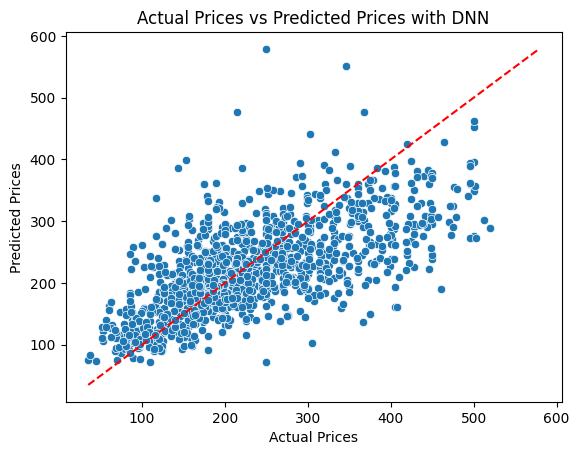

R2 score on test set: 0.4411623612492067
MSE on test set: 5563.099856044137


In [35]:
best_model = gs.best_estimator_

# Predict on the test set
y_pred = best_model.predict(X_test)

plot_pred_vs_true(y_pred, y_test, "DNN")

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

#save the results
results["DNN"] = {"r2": r2, "mse": mse}
print("R2 score on test set:", r2)
print("MSE on test set:", mse)


# Results comparison

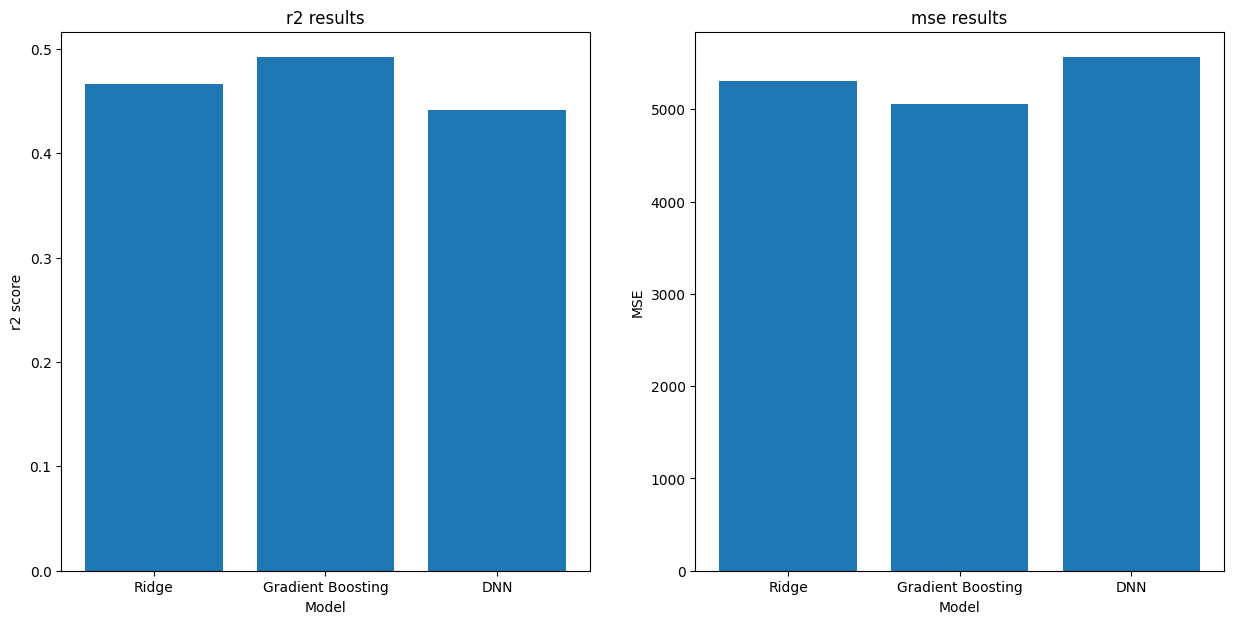

In [55]:
def plot_results(results, score, ax):
  models = results.keys()
  scores = [results[model][score] for model in models]
  ax.bar(models, scores)
  ax.set_title(f"{score} results")
  ax.set_xlabel("Model")
  ax.set_ylabel("r2 score") if score == "r2" else ax.set_ylabel("MSE")

fig, axs = plt.subplots(1,2, figsize = (15,7))

for i, score in enumerate(['r2', "mse"]):
  plot_results(results, score, axs[i])


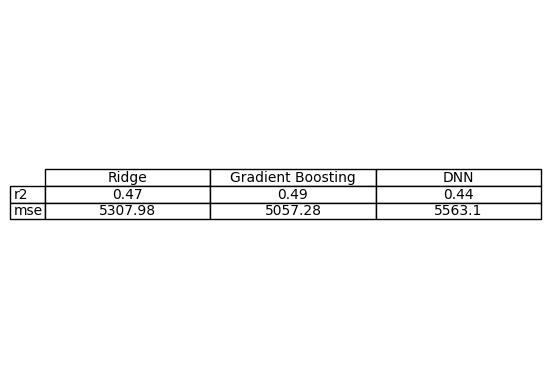

In [68]:
results_df = pd.DataFrame(results).round(2)
fix, ax = plt.subplots()
ax.axis('off')

table = pd.plotting.table(ax, results_df, loc='center',
                          cellLoc='center')

# Plot Network Architecture

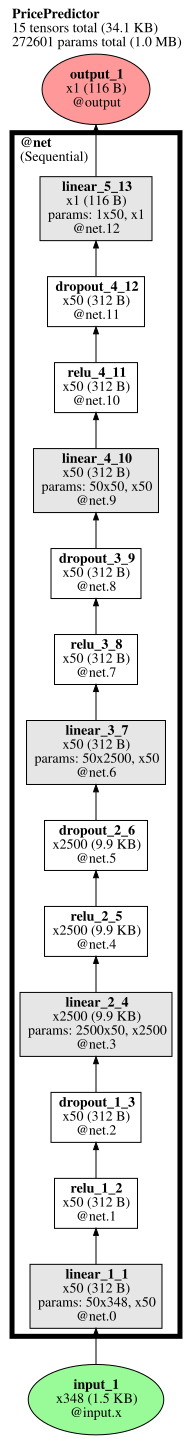

Log of PricePredictor forward pass:
	Random seed: 1542154646
	Time elapsed: 4.673s (4.67s spent logging)
	Structure:
		- purely feedforward, no recurrence
		- no branching
		- no conditional (if-then) branching
		- 14 total modules
	Tensor info:
		- 15 total tensors (34.1 KB) computed in forward pass.
		- 15 tensors (34.1 KB) with saved activations.
	Parameters: 5 parameter operations (272601 params total; 1.0 MB)
	Module Hierarchy:
		net
		    net.0, net.1, net.2, net.3, net.4, net.5, net.6, net.7, 
		    net.8, net.9, net.10, net.11, net.12
	Layers (all have saved activations):
		  (0) input_1 
		  (1) linear_1_1 
		  (2) relu_1_2 
		  (3) dropout_1_3 
		  (4) linear_2_4 
		  (5) relu_2_5 
		  (6) dropout_2_6 
		  (7) linear_3_7 
		  (8) relu_3_8 
		  (9) dropout_3_9 
		  (10) linear_4_10 
		  (11) relu_4_11 
		  (12) dropout_4_12 
		  (13) linear_5_13 
		  (14) output_1 


In [85]:
# #@title Plot Network Architecture (optional)
# !pip install torchlens


# import torchlens as tl
# x = X_train[0]
# model = PricePredictor(input_dim=X_train.shape[-1])
# model_history = tl.log_forward_pass(model, x, vis_opt='unrolled') # this automtically saves the pdf graph
# print(model_history)